In [2]:
import pandas as pd
import os
import argparse
import numpy as np
import pymc as pm
import arviz as az
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import ajr_causalpy_iv as ajr
import pytensor
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import xarray as xr

%reload_ext autoreload
%autoreload 2


In [3]:
# ---- Priors (aligned to standardized design) ----
# instruments (beta_t dims): [Intercept, logem4_std]
# structural (beta_z dims):  [Intercept, avexpr_std, logem4_std]  (only if loosen_exclusion=True)
priors_delta = {
    "mus": [
        [0.0, 0.0],                 # beta_t means: Intercept, logem4_std
        [0.0, 0.5537, -0.2946],         # beta_z means: Intercept, avexpr_std, logem4_std
    ],
    "sigmas": [
        [1.0, 1.0],                 # beta_t sds
        [1.0, 1.0, 1.0],           # beta_z sds (tight prior on logem4_std if loosened)
    ],
    "eta": 2,       # LKJ shape (correlations); η=2 = mild shrinkage toward 0A
    "lkj_sd": 2,    # rate for Exponential prior on residual SDs (if you kept Exponential)
}

data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"

# New loader returns (df, stats); we only need df here (run() standardizes internally)
df_ajr, stats = ajr.load_ajr_data(data_path, baseline_only=True, standardize=True)

# ---- Fit model ----
iv_obj, idata = ajr.run(
    data=df_ajr,              
    priors=priors_delta,
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    target_accept=0.9,
    loosen_exclusion=True,    
    covariates=None,          
    netcdf_path="ajr_iv_delta_posterior00.nc",
    standardize=True, 
    stats=stats        
)




Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations
Variables standardized (predictors) and centered (outcome).
First-stage formula: avexpr ~ 1 + logem4
Structural formula: logpgp95 ~ 1 + avexpr + logem4


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options

Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 60 seconds.
Sampling: [likelihood]


Output()

Posterior coefficients back-transformed to original units.
                    mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_z[Intercept]  0.002  0.088    -0.171      0.170      0.001    0.001   
beta_z[avexpr]     0.534  0.375    -0.201      1.298      0.012    0.008   
beta_z[logem4]    -0.437  0.208    -0.842     -0.008      0.006    0.004   
beta_t[Intercept]  0.001  0.109    -0.209      0.216      0.001    0.001   
beta_t[logem4]    -0.513  0.107    -0.719     -0.299      0.001    0.001   

                   ess_bulk  ess_tail  r_hat  
beta_z[Intercept]  4648.366  2829.215  1.001  
beta_z[avexpr]      991.284  1484.909  1.005  
beta_z[logem4]     1138.584  1789.092  1.004  
beta_t[Intercept]  5505.456  5010.694  1.001  
beta_t[logem4]     6251.597  5299.571  1.001  
                 mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_orig       0.367  0.257    -0.138      0.891      0.008    0.006   
delta_orig     -0.350  0.167    -0.674     -0.006      0

In [8]:
# ---- Priors (aligned to standardized design) ----
# instruments (beta_t dims): [Intercept, logem4_std]
# structural (beta_z dims):  [Intercept, avexpr_std, logem4_std]  (only if loosen_exclusion=True)
priors_delta = {
    "mus": [
        [0.0, 0.0],                 # beta_t means: Intercept, logem4_std
        [0.0, 0.0, 0.0],         # beta_z means: Intercept, avexpr_std, logem4_std
    ],
    "sigmas": [
        [1.0, 1.0],                 # beta_t sds
        [1.0, 1.0, 1.0],           # beta_z sds (tight prior on logem4_std if loosened)
    ],
    "eta": 2,       # LKJ shape (correlations); η=2 = mild shrinkage toward 0A
    "lkj_sd": 2,    # rate for Exponential prior on residual SDs (if you kept Exponential)
}

data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"

# New loader returns (df, stats); we only need df here (run() standardizes internally)
df_ajr, stats = ajr.load_ajr_data(data_path, baseline_only=True, standardize=True)

# ---- Fit model ----
iv_obj, idata = ajr.run(
    data=df_ajr,              
    priors=priors_delta,
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    target_accept=0.9,
    loosen_exclusion=True,    
    covariates=None,          
    netcdf_path="ajr_iv_delta_posterior03.nc",
    standardize=True, 
    stats=stats        
)

Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations
Variables standardized (predictors) and centered (outcome).
First-stage formula: avexpr ~ 1 + logem4
Structural formula: logpgp95 ~ 1 + avexpr + logem4


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z_raw, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 66 seconds.
Sampling: [likelihood]


Output()

Posterior coefficients back-transformed to original units.
                    mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_z[Intercept] -0.002  0.087    -0.179      0.166      0.001    0.001   
beta_z[avexpr]     0.489  0.376    -0.261      1.252      0.012    0.008   
beta_z[logem4]    -0.457  0.211    -0.902     -0.049      0.006    0.004   
beta_t[Intercept]  0.004  0.108    -0.201      0.212      0.001    0.001   
beta_t[logem4]    -0.513  0.108    -0.726     -0.306      0.002    0.001   

                   ess_bulk  ess_tail  r_hat  
beta_z[Intercept]  5809.758  4078.279  1.001  
beta_z[avexpr]      972.077  1492.074  1.004  
beta_z[logem4]     1104.487  1569.154  1.004  
beta_t[Intercept]  6061.060  5271.460  1.000  
beta_t[logem4]     5046.626  4540.012  1.001  
                 mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_orig       0.335  0.258    -0.179      0.859      0.008    0.006   
delta_orig     -0.366  0.169    -0.723     -0.039      0

In [5]:
mu_delta_std = -0.236 * stats["logem4"]["std"] 
print(f"Prior mean for delta (standardized): {mu_delta_std:.4f}")
mu_delta_sd_std = 0.1799 * stats["logem4"]["std"]
print(f"Prior sd for delta (standardized): {mu_delta_sd_std:.4f}")

mu_beta_std = 0.38 * stats["avexpr"]["std"]
print(f"Prior mean for beta (standardized): {mu_beta_std:.4f}")

Prior mean for delta (standardized): -0.2946
Prior sd for delta (standardized): 0.2245
Prior mean for beta (standardized): 0.5537


array([<Axes: title={'center': 'beta_orig'}>,
       <Axes: title={'center': 'delta_orig'}>,
       <Axes: title={'center': 'intercept_orig'}>], dtype=object)

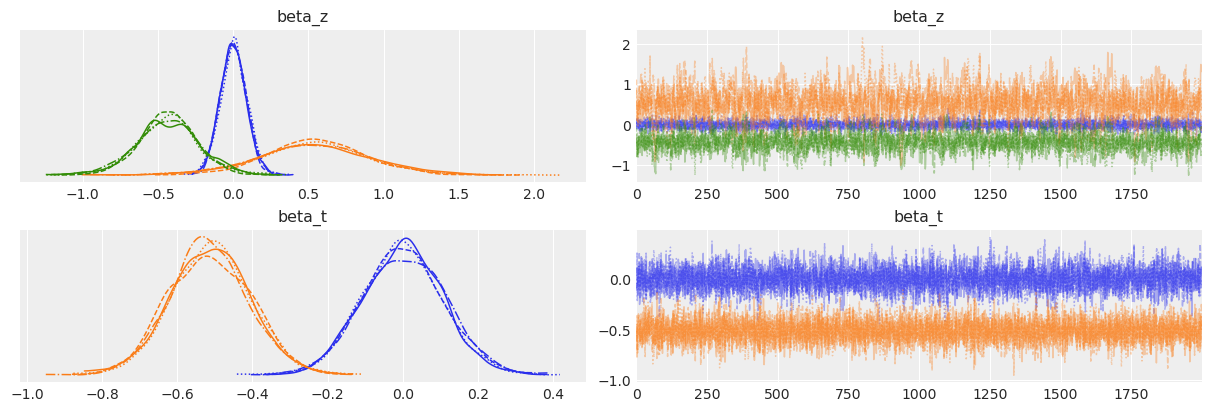

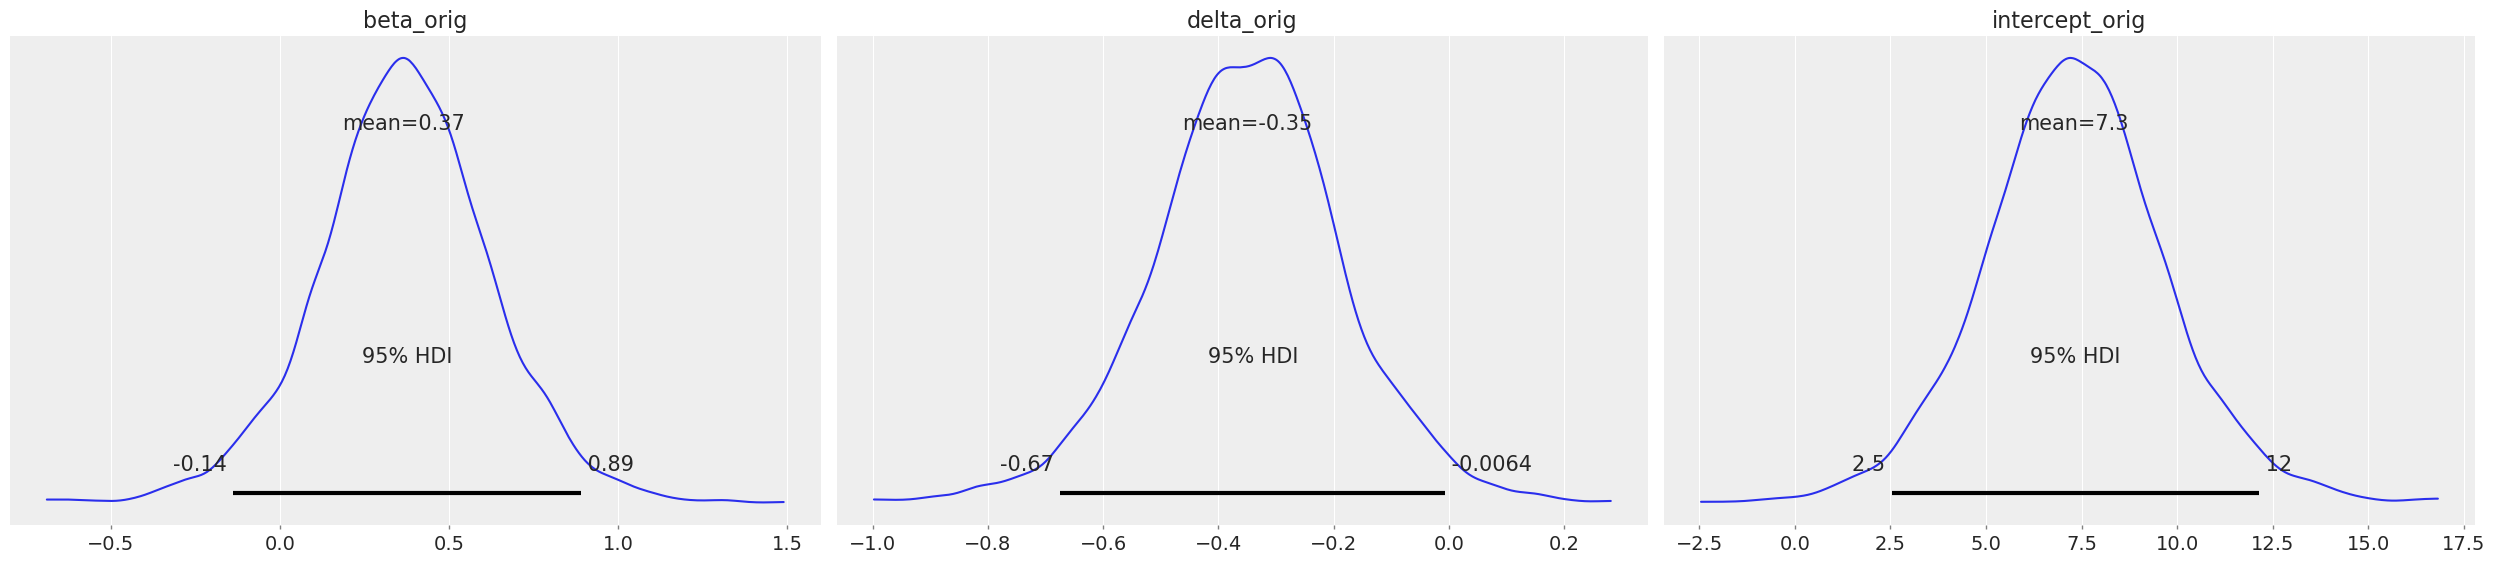

In [3]:
idata2 = az.from_netcdf("ajr_iv_delta_posterior00.nc")
az.plot_trace(idata2, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata2, var_names=["beta_orig", "delta_orig", "intercept_orig"], hdi_prob=0.95)


C:\Users\B375471\AppData\Local\Temp\ipykernel_8684\2187092070.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


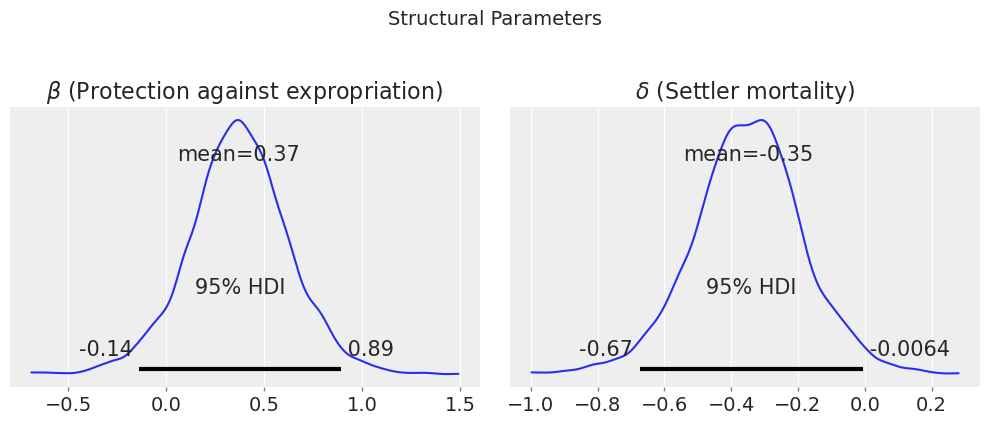

In [4]:


axes = az.plot_posterior(
    idata2,
    var_names=["beta_orig", "delta_orig"],
    hdi_prob=0.95,
    figsize=(10, 4),
    labeller=az.labels.MapLabeller(
        var_name_map={
            "beta_orig": r"$\beta$ (Protection against expropriation)",
            "delta_orig": r"$\delta$ (Settler mortality)"
        }
    )
)

# Extract the figure from one of the axes
fig = axes[0].get_figure()

# Add a shared title
fig.suptitle("Structural Parameters", fontsize=14, y=1.05)

plt.tight_layout()
plt.show()


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\seaborn\distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


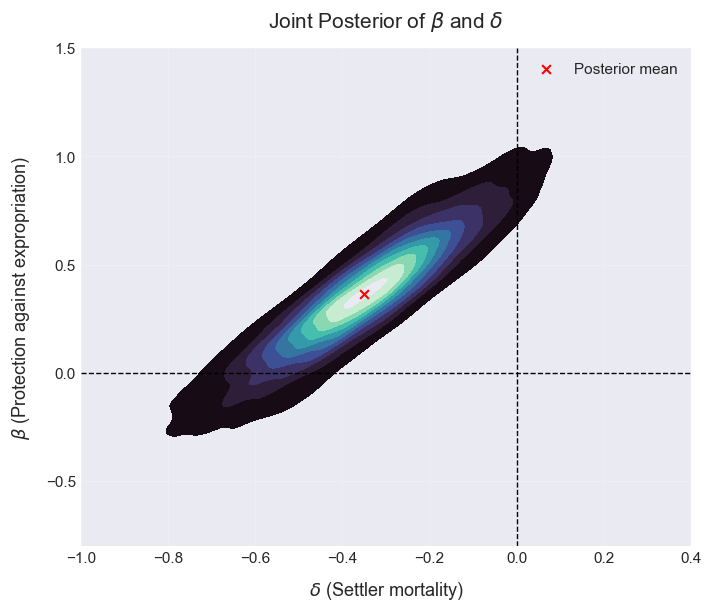

In [7]:


# Flatten posterior samples
beta = idata2.posterior["beta_orig"].values.flatten()
delta = idata2.posterior["delta_orig"].values.flatten()

# ---- Aesthetic setup ----
az.style.use("seaborn-v0_8-darkgrid")
plt.figure(figsize=(7, 6))

# ---- KDE contour ----
ax = sns.kdeplot(
    x=delta,
    y=beta,
    fill=True,
    levels=[0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95],
    cmap="mako",         # or "mako", "crest", "rocket", "cividis"
    linewidths=0.5
)

# ---- Labels and title ----
ax.set_xlabel(r"$\delta$ (Settler mortality)", fontsize=13, labelpad=10)
ax.set_ylabel(r"$\beta$ (Protection against expropriation)", fontsize=13, labelpad=10)
ax.set_title(r"Joint Posterior of $\beta$ and $\delta$", fontsize=15, pad=15)

# ---- Reference lines ----
ax.axvline(0, color="black", ls="--", lw=1)
ax.axhline(0, color="black", ls="--", lw=1)

# ---- Margins, ticks, and style ----
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="major", labelsize=11)
ax.grid(alpha=0.2)

# ---- Optional: mean point marker ----
ax.scatter(delta.mean(), beta.mean(), color="red", s=40, marker="x", label="Posterior mean")
ax.legend(frameon=False, loc="upper right", fontsize=11)
ax.set_xlim(-1.0, 0.4)
ax.set_ylim(-0.8, 1.5)


plt.show()



array([<Axes: title={'center': 'Structural parameters\nProtection against expropriation'}>,
       <Axes: title={'center': 'Structural parameters\nSettler mortality'}>],
      dtype=object)

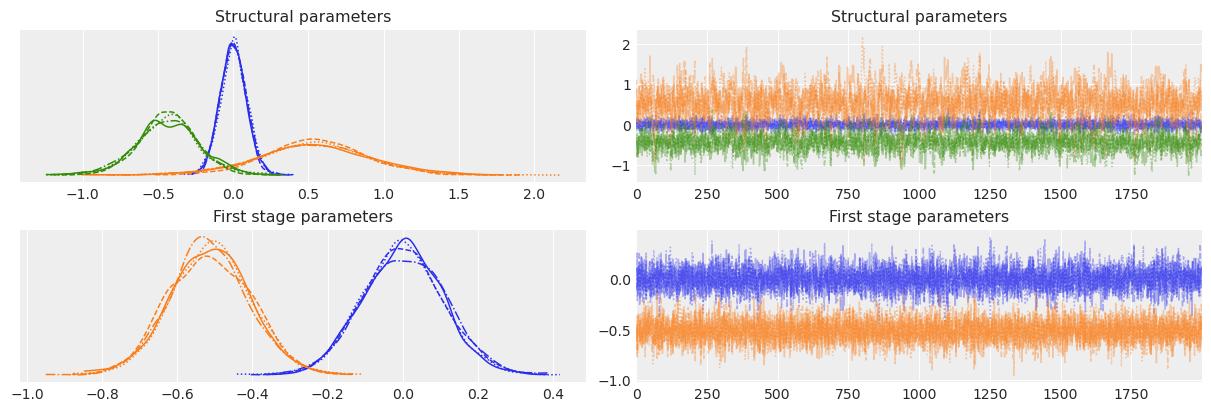

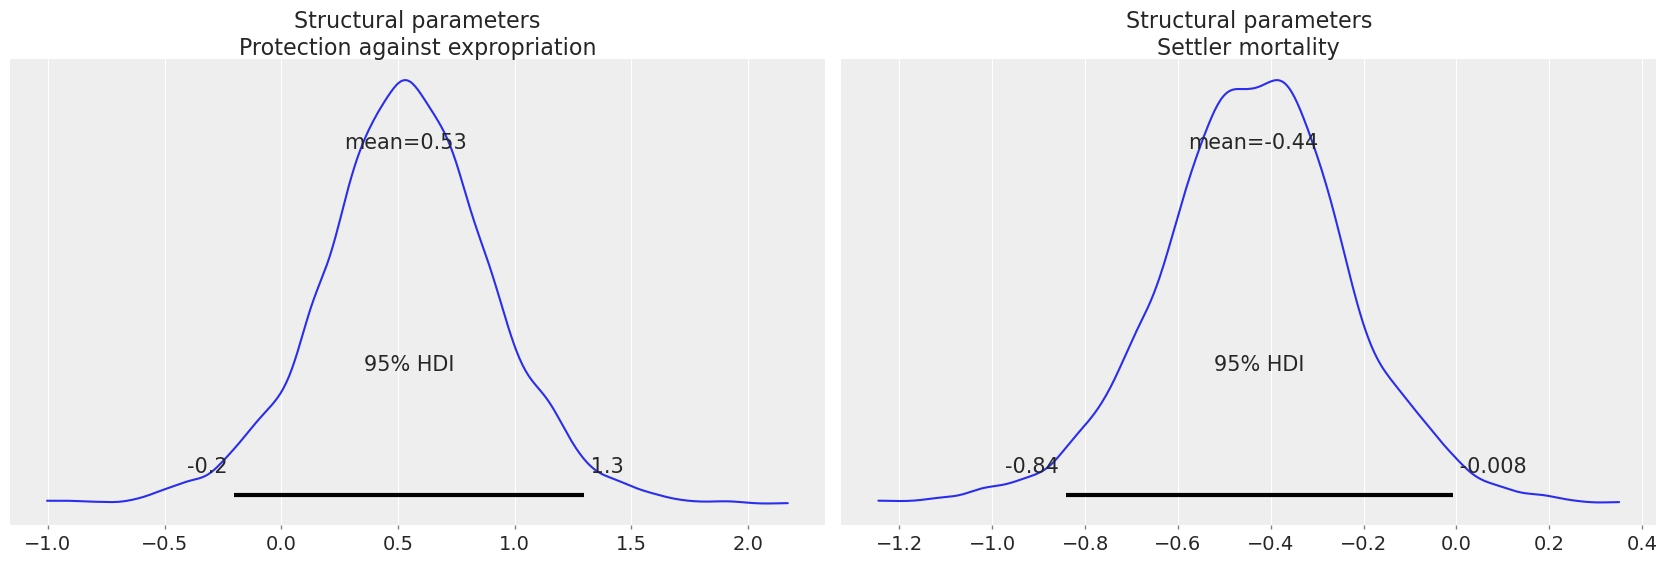

In [5]:
az.plot_trace(
    idata2,
    var_names=["beta_z", "beta_t"],
    labeller=az.labels.MapLabeller(
        var_name_map={"beta_z": "Structural parameters", "beta_t": "First stage parameters"}
    )
)



idata2_plot = idata2.copy()

# Find which dimension indexes beta_z (often "beta_z_dim_0" or similar)
dim_name = idata2_plot.posterior["beta_z"].dims[-1]

# Replace the coordinate label
idata2_plot.posterior = idata2_plot.posterior.assign_coords({
    dim_name: [
        "Intercept" if x == "Intercept" else
        "Protection against expropriation" if x == "avexpr" else
        "Settler mortality" if x == "logem4" else x
        for x in idata2_plot.posterior[dim_name].values
    ]
})

coef_dim = idata2_plot.posterior["beta_z"].dims[-1]
idata_no_intercept = idata2_plot.copy()
idata_no_intercept.posterior = idata_no_intercept.posterior.drop_sel({coef_dim: "Intercept"})

az.plot_posterior(
    idata_no_intercept,
    var_names=["beta_z"],
    hdi_prob=0.95,
    labeller=az.labels.MapLabeller(var_name_map={"beta_z": "Structural parameters"})
)

C:\Users\B375471\AppData\Local\Temp\ipykernel_7624\28355347.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


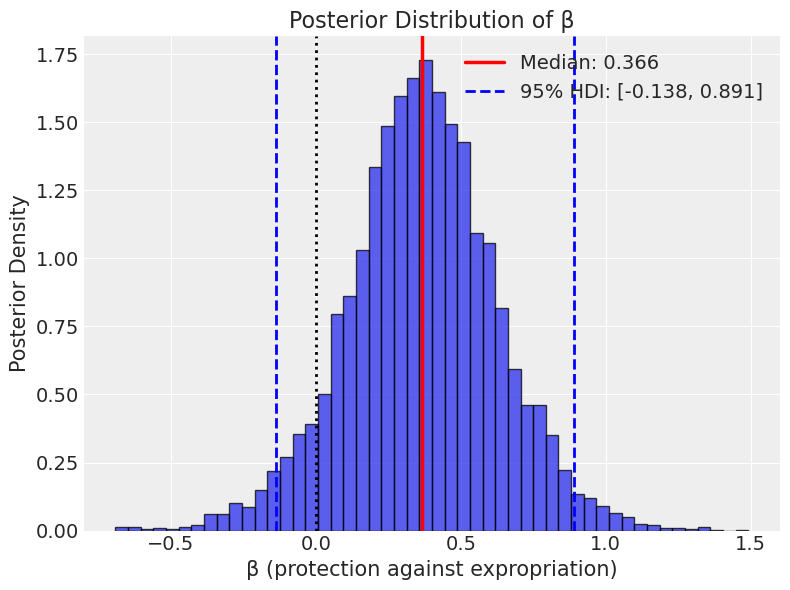

β median: 0.366 | 95% HDI: [-0.138, 0.891] | Contains 0: True


In [4]:


posterior = idata2.posterior
y_obs = df_ajr["logpgp95"].to_numpy()
z_inst = df_ajr["logem4"].to_numpy()

# ---------- Build structural predictions: yhat(chain, draw, obs) ----------
def find_obs_dim(da):
    for cand in ("obs", "observation", "i", "n", "N", "obs_id"):
        if cand in da.dims:
            return cand
    return None

beta_z = posterior["beta_z"]
obs_dim = find_obs_dim(beta_z)

if obs_dim is not None:
    structural_preds = beta_z  # already (chain, draw, obs)
else:
    if "covariates" not in beta_z.dims:
        raise ValueError(f"'beta_z' needs obs dim or 'covariates'. Got {beta_z.dims}.")
    covs_all = [str(c) for c in beta_z.coords["covariates"].values]
    intercept_names = {"Intercept", "intercept", "const", "Constant", "_cons"}
    use_explicit_intercept = "intercept_orig" in posterior.data_vars
    covs = [c for c in covs_all if not (use_explicit_intercept and c in intercept_names)]

    n_obs = len(df_ajr)
    cols = []
    for c in covs:
        if c in intercept_names:
            cols.append(np.ones((n_obs, 1)))  # only if no explicit intercept param
        else:
            if c not in df_ajr.columns:
                raise KeyError(f"Missing covariate in df_ajr: {c!r}")
            cols.append(df_ajr[c].to_numpy().reshape(-1, 1))
    X = np.hstack(cols) if cols else np.zeros((n_obs, 0))

    B = beta_z.sel(covariates=covs).values                      # (chain, draw, K)
    yhat = np.einsum("cdk,nk->cdn", B, X) if X.shape[1] else np.zeros(B.shape[:2] + (n_obs,))
    if use_explicit_intercept:
        yhat = yhat + posterior["intercept_orig"].values[..., None]

    structural_preds = xr.DataArray(
        yhat, dims=("chain","draw","obs"),
        coords={
            "chain": posterior.get("chain", xr.DataArray(np.arange(yhat.shape[0]), dims="chain")).values,
            "draw":  posterior.get("draw",  xr.DataArray(np.arange(yhat.shape[1]), dims="draw")).values,
            "obs":   np.arange(n_obs),
        },
        name="structural_preds",
    )

# Residuals at posterior mean (for scatter)
median_pred = structural_preds.mean(("chain","draw")).values
median_res  = y_obs - median_pred          # should be ~centered

# ---------- Grab the same beta_orig ArviZ is plotting ----------
beta_da = idata2.posterior["beta_orig"]

# If beta has a covariate dimension, pick the same one ArviZ uses
if "covariates" in beta_da.dims:
    if "avexpr" in beta_da.coords["covariates"].values:
        beta_da = beta_da.sel(covariates="avexpr")
    else:
        beta_da = beta_da.isel(covariates=0)

# Flatten chains/draws and drop NaNs/Infs
beta_samples = np.ravel(beta_da.values).astype(float)
beta_samples = beta_samples[np.isfinite(beta_samples)]

# Use HDI (to match az.plot_posterior)
hdi_lo, hdi_hi = az.hdi(beta_samples, hdi_prob=0.95)
beta_med = float(np.median(beta_samples))

# ---------- Make the figure (β-based version) ----------
fig, ax2 = plt.subplots(figsize=(8, 6))

# Density plot (hist ok; ArviZ uses KDE, but HDI numbers will match now)
ax2.hist(beta_samples, bins=50, density=True, alpha=0.75, edgecolor="black")

# Annotations that now match ArviZ's HDI
ax2.axvline(beta_med, color="red", linewidth=2.5, label=f"Median: {beta_med:.3f}")
ax2.axvline(hdi_lo,  color="blue", linestyle="--", linewidth=2.0)
ax2.axvline(hdi_hi,  color="blue", linestyle="--", linewidth=2.0)
ax2.legend([plt.Line2D([], [], color='red', lw=2.5),
            plt.Line2D([], [], color='blue', lw=2.0, ls='--')],
           [f"Median: {beta_med:.3f}",
            f"95% HDI: [{hdi_lo:.3f}, {hdi_hi:.3f}]"])

ax2.axvline(0.0, color="black", linestyle=":", linewidth=2.0, label="Zero")
ax2.set_xlabel("β (protection against expropriation)")
ax2.set_ylabel("Posterior Density")
ax2.set_title("Posterior Distribution of β")

plt.tight_layout()
plt.show()

print(f"β median: {beta_med:.3f} | 95% HDI: [{hdi_lo:.3f}, {hdi_hi:.3f}] | Contains 0: {hdi_lo <= 0 <= hdi_hi}")


#### Simulations over delta-space

In [5]:
# ---- 1) Choose a grid of *fixed* δ values (violations of exclusion)
delta_grid = np.linspace(-0.5, 0.0, 8)   

# ---- 2) Decide covariates 
data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df_ajr, stats = ajr.load_ajr_data(data_path, baseline_only=True, standardize=True)
covariates = []  # or None

# Helper to build priors that FIX δ at delta0 
def priors_fix_delta(delta0, covariates=None):
    # infer lengths so the prior vectors match 
    p = len(covariates) if covariates else 0
    FLAT = 1                        

    
    # First-stage: [intercept, covs..., logem4]
    mus_t = [0] + [0]*p + [0]         
    sig_t = [FLAT] + [FLAT]*p + [FLAT] 
    
    # Structural: [intercept, avexpr, covs..., logem4(delta)]
    mus_z = [0] + [0]*p + [0.38] + [delta0] # delta (logem4 coeff) gets mean delta0
    sig_z = [FLAT] + [FLAT]*p +[FLAT] + [1e-6] # delta gets tiny sd (fixed)] 

    return {
        "mus":    [mus_t, mus_z],
        "sigmas": [sig_t, sig_z],
        "eta":    2,      # LKJ on residual corr 
        "lkj_sd": 2,      # Scale on sigmas 
    }

# ---- 3) Run the grid and collect summaries


fits, labels, rows = [], [], []
for i, d0 in enumerate(tqdm(delta_grid, desc="Delta grid simulation")):
    print(f"\n--- Running δ = {d0:+.2f} ({i+1}/{len(delta_grid)}) ---")
    
    pri = priors_fix_delta(d0, covariates=covariates)
    out = f"ajr_iv_fixdelta_{d0:+.2f}.nc"

    # Debug: Print prior structure
    print(f"First-stage equation mus: {pri['mus'][0]}")  # beta_z is structural
    print(f"Structural equation mus: {pri['mus'][1]}")  # beta_t is first-stage
    print(f"Expected: delta in first-stage = {d0} with tiny sd")

    iv, idata = ajr.run(
        data = df_ajr,
        loosen_exclusion=True,
        covariates=None,
        priors=pri,                   # δ fixed at d0
        draws=2000, tune=1000, chains=4, cores=4,
        target_accept=0.95,
        netcdf_path=out,
        stats=stats,
        standardize=True,
    )

    fits.append(idata); labels.append(f"δ={d0:+.2f}")
    
    # Understanding the correct structure
    print("Beta_z coordinates (STRUCTURAL eq):", list(idata.posterior.coords['covariates'].values))
    print("Beta_t coordinates (FIRST-STAGE eq):", list(idata.posterior.coords['instruments'].values))
    
    covariates_list = list(idata.posterior.coords['covariates'].values)
    instruments_list = list(idata.posterior.coords['instruments'].values)
    
    # Find avexpr coefficient in STRUCTURAL equation (beta_z)
    try:
        avexpr_idx = covariates_list.index('avexpr')
    except ValueError:
        # If not found by name, assume it's at index 1 (after intercept)
        avexpr_idx = 1
        print(f"Warning: 'avexpr' not found in covariates, using index 1")
    
    # Find logem4 coefficient in FIRST-STAGE equation (beta_t) 
    try:
        logem4_idx = instruments_list.index('logem4')
    except ValueError:
        # If not found by name, use last index
        logem4_idx = -1
        print(f"Warning: 'logem4' not found in instruments, using last index")
    
    # Extract coefficients from CORRECT equations
    avexpr_coeff = idata.posterior["beta_z"].isel(covariates=avexpr_idx)  # STRUCTURAL: avexpr effect on logpgp95
    delta_coeff = idata.posterior["beta_z"].isel(covariates=logem4_idx)   # FIRST-STAGE: delta (logem4 effect on avexpr)
    
    avexpr_mean = float(avexpr_coeff.mean())
    delta_mean = float(delta_coeff.mean())
    
    # FIXED: HDI for avexpr coefficient using numpy percentiles as fallback
    try:
        avexpr_hdi = az.hdi(avexpr_coeff)
        print(f"HDI type: {type(avexpr_hdi)}")
        print(f"HDI structure: {avexpr_hdi}")
        
        # Try different extraction methods
        if hasattr(avexpr_hdi, 'data_vars'):
            # It's a Dataset
            var_name = list(avexpr_hdi.data_vars.keys())[0]
            hdi_array = avexpr_hdi[var_name].values
            hdi_low = float(hdi_array[0])
            hdi_high = float(hdi_array[1])
        else:
            # It's a DataArray
            hdi_array = avexpr_hdi.values
            hdi_low = float(hdi_array[0])
            hdi_high = float(hdi_array[1])
            
    except Exception as e:
        print(f"HDI extraction failed: {e}")
        # Fallback to manual percentiles
        avexpr_samples = avexpr_coeff.values.flatten()
        hdi_low = float(np.percentile(avexpr_samples, 2.5))
        hdi_high = float(np.percentile(avexpr_samples, 97.5))
    
    rows.append({
        "delta_fixed": d0,
        "delta_actual_mean": delta_mean,  # Should be close to d0
        "avexpr_causal_effect": avexpr_mean,  # This is the causal effect of institutions
        "avexpr_hdi_low": hdi_low,
        "avexpr_hdi_high": hdi_high,
        "delta_sd_used": 1e-6,
        "file": out
    })
    
    print(f"✓ δ fixed at {d0:+.2f}, actual mean: {delta_mean:+.3f}")
    print(f"  Avexpr causal effect: {avexpr_mean:.3f}")
    print(f"  HDI: [{hdi_low:.3f}, {hdi_high:.3f}]")
    print(f"  Available covariates (beta_z): {covariates_list}")
    print(f"  Available instruments (beta_t): {instruments_list}")
    print(f"  Used avexpr_idx={avexpr_idx}, logem4_idx={logem4_idx}")

summary = pd.DataFrame(rows).sort_values("delta_fixed")
print("\n=== SUMMARY TABLE ===")
summary

Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations
Variables standardized (predictors) and centered (outcome).


Delta grid simulation:   0%|          | 0/8 [00:00<?, ?it/s]


--- Running δ = -0.50 (1/8) ---
First-stage equation mus: [0, 0]
Structural equation mus: [0, 0.38, np.float64(-0.5)]
Expected: delta in first-stage = -0.5 with tiny sd
First-stage formula: avexpr ~ 1 + logem4
Structural formula: logpgp95 ~ 1 + avexpr + logem4


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z_raw, chol_cov]


Output()

...

Output()

Posterior coefficients back-transformed to original units.


Delta grid simulation: 100%|██████████| 8/8 [14:39<00:00, 109.99s/it]

                    mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_z[Intercept]  0.000  0.111    -0.226      0.214      0.002    0.001   
beta_z[avexpr]     1.241  0.175     0.924      1.603      0.004    0.002   
beta_z[logem4]     0.000  0.000    -0.000      0.000      0.000    0.000   
beta_t[Intercept] -0.002  0.109    -0.212      0.213      0.002    0.001   
beta_t[logem4]    -0.561  0.098    -0.748     -0.364      0.002    0.001   

                   ess_bulk  ess_tail  r_hat  
beta_z[Intercept]  5014.020  4602.060  1.001  
beta_z[avexpr]     2464.660  3282.831  1.001  
beta_z[logem4]     6108.116  4608.051  1.000  
beta_t[Intercept]  5191.629  5060.183  1.001  
beta_t[logem4]     4055.576  4722.167  1.001  
                 mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_orig       0.852  0.120     0.634      1.100      0.002    0.002   
delta_orig      0.000  0.000    -0.000      0.000      0.000    0.000   
intercept_orig  2.511  0.781     0.892    

,delta_fixed,delta_actual_mean,avexpr_causal_effect,avexpr_hdi_low,avexpr_hdi_high,delta_sd_used,file
0,-0.500000,0.426754,0.426754,0.160740,0.712573,0.000001,ajr_iv_fixdelta_-0.50.nc
1,-0.428571,0.544702,0.544702,0.278360,0.824938,0.000001,ajr_iv_fixdelta_-0.43.nc
2,-0.357143,0.662303,0.662303,0.401519,0.953698,0.000001,ajr_iv_fixdelta_-0.36.nc
3,-0.285714,0.780075,0.780075,0.508308,1.059163,0.000001,ajr_iv_fixdelta_-0.29.nc
4,-0.214286,0.897433,0.897433,0.617005,1.193155,0.000001,ajr_iv_fixdelta_-0.21.nc
5,-0.142857,1.014735,1.014735,0.727233,1.328017,0.000001,ajr_iv_fixdelta_-0.14.nc
6,-0.071429,1.123973,1.123973,0.830918,1.446333,0.000001,ajr_iv_fixdelta_-0.07.nc
7,0.000000,1.241403,1.241403,0.929806,1.578216,0.000001,ajr_iv_fixdelta_+0.00.nc


   delta_fixed  delta_actual_mean  avexpr_causal_effect  avexpr_hdi_low  \
0    -0.500000      -4.006035e-01              0.292874        0.090678   
1    -0.428571      -3.433744e-01              0.373819        0.178797   
2    -0.357143      -2.861453e-01              0.454526        0.261889   
3    -0.285714      -2.289163e-01              0.535351        0.330282   
4    -0.214286      -1.716872e-01              0.615892        0.417064   
5    -0.142857      -1.144581e-01              0.696394        0.489988   
6    -0.071429      -5.722907e-02              0.771362        0.558234   
7     0.000000       2.607956e-10              0.851952        0.634025   

   avexpr_hdi_high  delta_sd_used                      file  
0         0.484863       0.000001  ajr_iv_fixdelta_-0.50.nc  
1         0.571028       0.000001  ajr_iv_fixdelta_-0.43.nc  
2         0.659241       0.000001  ajr_iv_fixdelta_-0.36.nc  
3         0.726708       0.000001  ajr_iv_fixdelta_-0.29.nc  
4         0.83

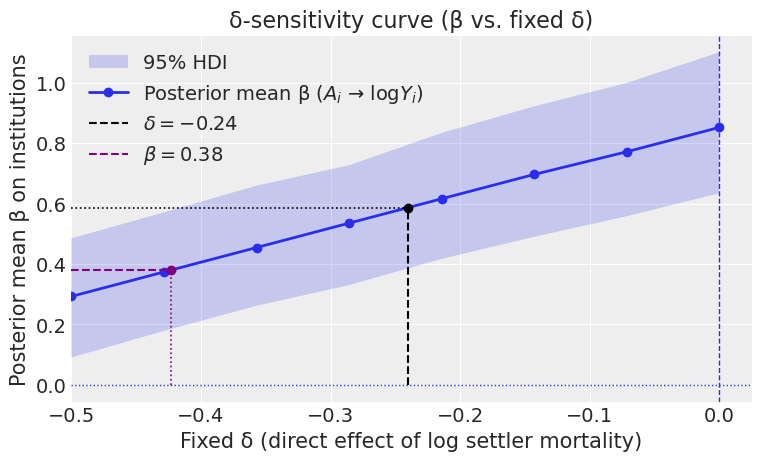

In [16]:


# ---- 1) The same grid used to run the model ----------------------------------
delta_grid = np.linspace(-0.5, 0.0, 8) 
def nc_name(d): 
    return f"ajr_iv_fixdelta_{d:+.2f}.nc"  

rows = []

for d0 in delta_grid:
    fname = nc_name(d0)
    if not os.path.exists(fname):
        print(f"WARNING: missing file {fname} — skipping")
        continue

    # Load inference data
    idata = az.from_netcdf(fname)

    # Get coordinate labels
    covars = list(idata.posterior.coords.get("covariates", []).values)
    instrs = list(idata.posterior.coords.get("instruments", []).values)

    # Find indices safely
    # Structural eq: beta_z over "covariates" (contains 'avexpr' and 'logem4')
    try:
        avexpr_idx = covars.index("avexpr")
    except Exception:
        avexpr_idx = 1  # fallback: intercept at 0, avexpr next
        print(f"NOTE: 'avexpr' not found in covariates; using index {avexpr_idx}")

    try:
        logem4_idx = covars.index("logem4")  # δ lives in STRUCTURAL coeffs here
    except Exception:
        logem4_idx = len(covars) - 1  # fallback: assume last
        print(f"NOTE: 'logem4' not found in covariates; using last index {logem4_idx}")

    # Extract draws
    post = idata.posterior
    avexpr_draws = post["beta_orig"].values.ravel()
    delta_draws  = post["delta_orig"].values.ravel()

    # Summary stats
    avexpr_mean = float(np.mean(avexpr_draws))
    # Try HDI first; if it fails, use equal-tail percentiles
    try:
        hdi = az.hdi(avexpr_draws, hdi_prob=0.95)
        # az.hdi may return shape (2,), make sure to order low<high
        lo, hi = float(np.min(hdi)), float(np.max(hdi))
    except Exception:
        lo, hi = float(np.percentile(avexpr_draws, 2.5)), float(np.percentile(avexpr_draws, 97.5))

    delta_mean = float(np.mean(delta_draws))

    rows.append({
        "delta_fixed": float(d0),
        "delta_actual_mean": delta_mean,
        "avexpr_causal_effect": avexpr_mean,
        "avexpr_hdi_low": lo,
        "avexpr_hdi_high": hi,
        "delta_sd_used": 1e-6,   # as in your prior
        "file": fname
    })

# ---- 2) Create DataFrame -----------------------------------------------------
df = pd.DataFrame(rows).sort_values("delta_fixed").reset_index(drop=True)
print(df)

# ---- 3) Plot the delta-sensitivity curve ------------------------------------
x  = df["delta_fixed"].to_numpy()
y  = df["avexpr_causal_effect"].to_numpy()
lo = df["avexpr_hdi_low"].to_numpy()
hi = df["avexpr_hdi_high"].to_numpy()

plt.figure(figsize=(7.5, 4.5))
plt.fill_between(x, lo, hi, alpha=0.2, label="95% HDI")
plt.plot(x, y, marker="o", linewidth=2, label="Posterior mean β ($A_i$ → log$Y_i$)")

# --------------------------------------------------------------------------
# 1) Highlight δ = -0.24
# --------------------------------------------------------------------------
delta_highlight = -0.24
beta_highlight = np.interp(delta_highlight, x, y)

# Vertical + horizontal reference lines
plt.plot([delta_highlight, delta_highlight], [0, beta_highlight],
         color="black", linestyle="--", linewidth=1.5, label=r"$\delta=-0.24$")
plt.plot([x.min(), delta_highlight], [beta_highlight, beta_highlight],
         color="black", linestyle=":", linewidth=1.2)
plt.scatter(delta_highlight, beta_highlight, color="black", zorder=5)



# --------------------------------------------------------------------------
# 2) Highlight β = 0.38
# --------------------------------------------------------------------------
beta_ref = 0.38
# Interpolate corresponding δ value
delta_ref = np.interp(beta_ref, y, x)

# Horizontal + vertical reference lines
plt.plot([x.min(), delta_ref], [beta_ref, beta_ref],
         color="purple", linestyle="--", linewidth=1.5, label=r"$\beta=0.38$")
plt.plot([delta_ref, delta_ref], [0, beta_ref],
         color="purple", linestyle=":", linewidth=1.2)
plt.scatter(delta_ref, beta_ref, color="purple", zorder=5)



# --------------------------------------------------------------------------
# Formatting
# --------------------------------------------------------------------------
plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle=":", linewidth=1)
plt.title("δ-sensitivity curve (β vs. fixed δ)")
plt.xlabel("Fixed δ (direct effect of log settler mortality)")
plt.ylabel("Posterior mean β on institutions")
plt.legend(loc="best")
plt.xlim(-0.5, None)
plt.savefig("delta_sensitivity_curve_highlighted.png", dpi=160, bbox_inches="tight")
plt.show()


In [4]:
# ---- Priors (aligned to standardized design) ----
# instruments (beta_t dims): [Intercept, logem4_std]
# structural (beta_z dims):  [Intercept, avexpr_std, logem4_std]  (only if loosen_exclusion=True)
priors_delta = {
    "mus": [
        [0.0, 0.0],                 # beta_t means: Intercept, logem4_std
        [0.0, 0.5537, -0.2946],         # beta_z means: Intercept, avexpr_std, logem4_std
    ],
    "sigmas": [
        [1.0, 1.0],                 # beta_t sds
        [1.0, 1.0, 1.0],           # beta_z sds (tight prior on logem4_std if loosened)
    ],
    "eta": 2,       # LKJ shape (correlations); η=2 = mild shrinkage toward 0A
    "lkj_sd": 2,    # rate for Exponential prior on residual SDs (if you kept Exponential)
    "S": 0.46,      # Sensitivity parameter S (larger = wider delta prior)
}

data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"

# New loader returns (df, stats); we only need df here (run() standardizes internally)
df_ajr, stats = ajr.load_ajr_data(data_path, baseline_only=True, standardize=True)

# ---- Fit model ----
iv_obj, idata = ajr.run(
    data=df_ajr,              
    priors=priors_delta,
    draws=2000,
    tune=1000,
    chains=4,
    cores=4,
    target_accept=0.9,
    loosen_exclusion=True,    
    covariates=None,          
    netcdf_path="ajr_iv_delta_posterior07.nc",
    standardize=True, 
    stats=stats        
)


Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations
Variables standardized (predictors) and centered (outcome).
First-stage formula: avexpr ~ 1 + logem4
Structural formula: logpgp95 ~ 1 + avexpr + logem4


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z_raw, delta_cond, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 67 seconds.
Sampling: [likelihood]


Output()

Posterior coefficients back-transformed to original units.
                    mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_z[Intercept]  0.000  0.086    -0.168      0.171      0.001    0.001   
beta_z[avexpr]     0.802  0.243     0.393      1.303      0.006    0.006   
beta_z[logem4]    -0.281  0.140    -0.528      0.001      0.003    0.003   
beta_t[Intercept] -0.000  0.105    -0.199      0.207      0.001    0.001   
beta_t[logem4]    -0.516  0.109    -0.738     -0.308      0.001    0.001   

                   ess_bulk  ess_tail  r_hat  
beta_z[Intercept]  7267.539  4983.907  1.001  
beta_z[avexpr]     1838.192  1740.960  1.002  
beta_z[logem4]     2304.611  2273.216  1.002  
beta_t[Intercept]  6404.215  5624.533  1.000  
beta_t[logem4]     7312.980  5454.480  1.000  
                 mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_orig       0.550  0.167     0.270      0.894      0.004    0.004   
delta_orig     -0.225  0.112    -0.423      0.001      0

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


array([<Axes: title={'center': 'beta_orig'}>,
       <Axes: title={'center': 'delta_orig'}>,
       <Axes: title={'center': 'intercept_orig'}>], dtype=object)

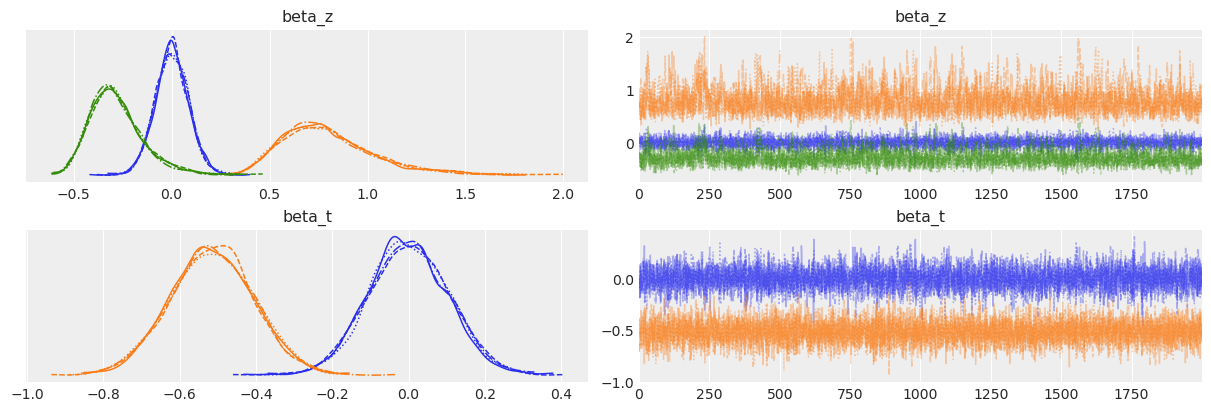

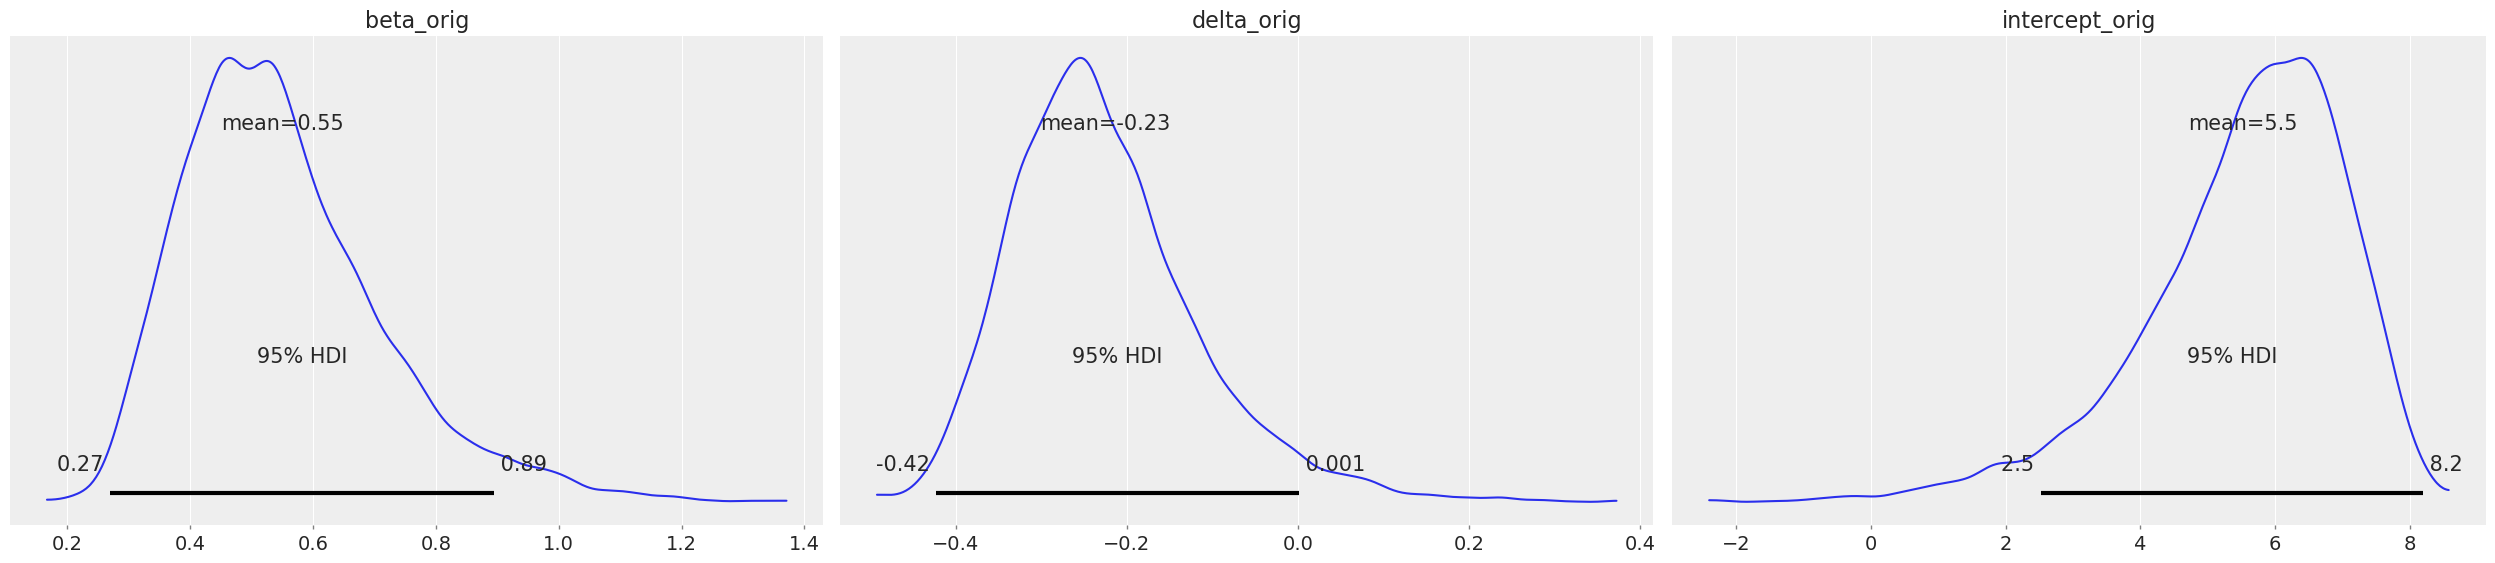

In [5]:
idata3 = az.from_netcdf("ajr_iv_delta_posterior07.nc")
az.plot_trace(idata3, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata3, var_names=["beta_orig", "delta_orig", "intercept_orig"], hdi_prob=0.95)


array([<Axes: title={'center': 'Structural parameters\nProtection against expropriation'}>,
       <Axes: title={'center': 'Structural parameters\nSettler mortality'}>],
      dtype=object)

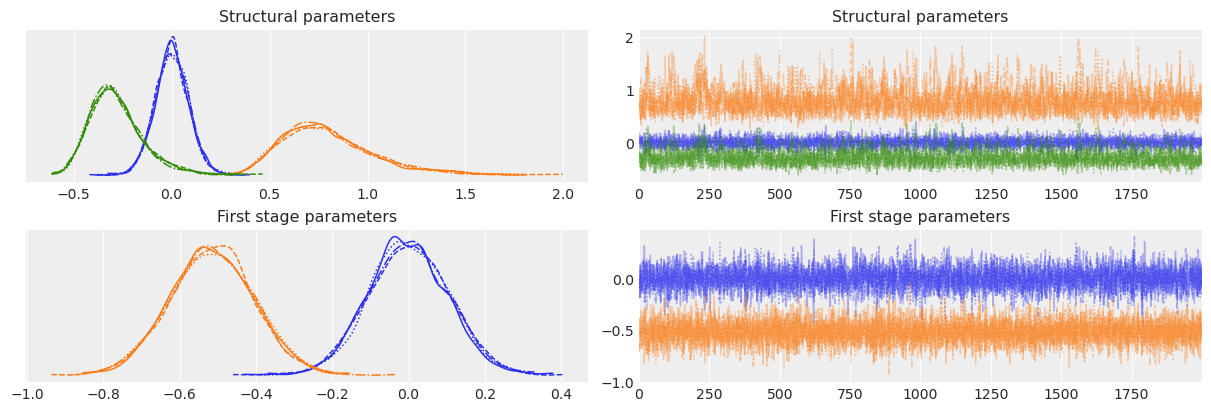

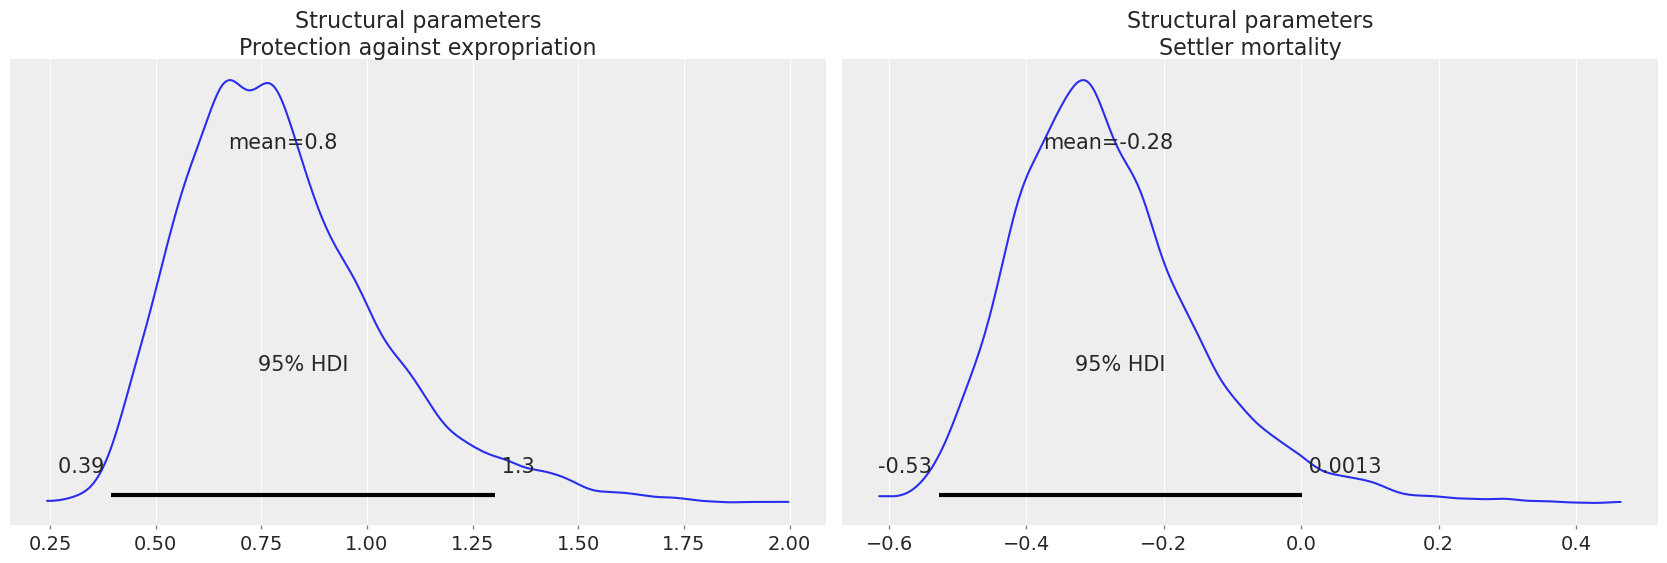

In [19]:
az.plot_trace(
    idata3,
    var_names=["beta_z", "beta_t"],
    labeller=az.labels.MapLabeller(
        var_name_map={"beta_z": "Structural parameters", "beta_t": "First stage parameters"}
    )
)



idata3_plot = idata3.copy()

# Find which dimension indexes beta_z (often "beta_z_dim_0" or similar)
dim_name = idata3_plot.posterior["beta_z"].dims[-1]

# Replace the coordinate label
idata3_plot.posterior = idata3_plot.posterior.assign_coords({
    dim_name: [
        "Intercept" if x == "Intercept" else
        "Protection against expropriation" if x == "avexpr" else
        "Settler mortality" if x == "logem4" else x
        for x in idata3_plot.posterior[dim_name].values
    ]
})

coef_dim = idata3_plot.posterior["beta_z"].dims[-1]
idata_no_intercept = idata3_plot.copy()
idata_no_intercept.posterior = idata_no_intercept.posterior.drop_sel({coef_dim: "Intercept"})

az.plot_posterior(
    idata_no_intercept,
    var_names=["beta_z"],
    hdi_prob=0.95,
    labeller=az.labels.MapLabeller(var_name_map={"beta_z": "Structural parameters"})
)

C:\Users\B375471\AppData\Local\Temp\ipykernel_7624\2708814986.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


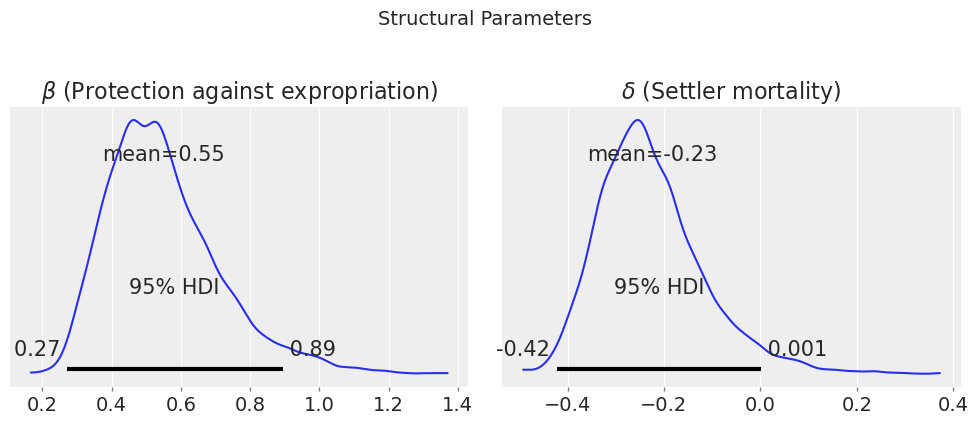

In [20]:


axes = az.plot_posterior(
    idata3,
    var_names=["beta_orig", "delta_orig"],
    hdi_prob=0.95,
    figsize=(10, 4),
    labeller=az.labels.MapLabeller(
        var_name_map={
            "beta_orig": r"$\beta$ (Protection against expropriation)",
            "delta_orig": r"$\delta$ (Settler mortality)"
        }
    )
)

# Extract the figure from one of the axes
fig = axes[0].get_figure()

# Add a shared title
fig.suptitle("Structural Parameters", fontsize=14, y=1.05)

plt.tight_layout()
plt.show()

C:\Users\B375471\AppData\Local\Temp\ipykernel_7624\2026964645.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


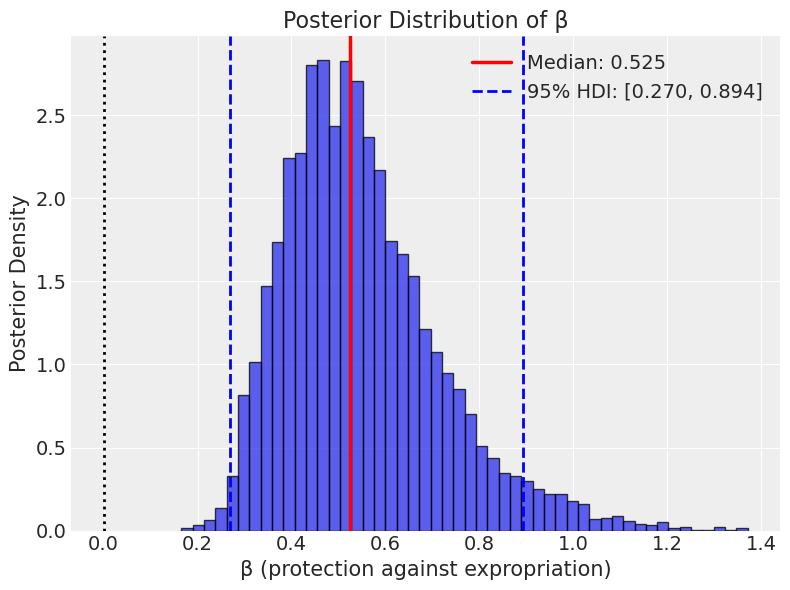

β median: 0.525 | 95% HDI: [0.270, 0.894] | Contains 0: False


In [21]:
posterior = idata3.posterior
y_obs = df_ajr["logpgp95"].to_numpy()
z_inst = df_ajr["logem4"].to_numpy()

# ---------- Build structural predictions: yhat(chain, draw, obs) ----------
def find_obs_dim(da):
    for cand in ("obs", "observation", "i", "n", "N", "obs_id"):
        if cand in da.dims:
            return cand
    return None

beta_z = posterior["beta_z"]
obs_dim = find_obs_dim(beta_z)

if obs_dim is not None:
    structural_preds = beta_z  # already (chain, draw, obs)
else:
    if "covariates" not in beta_z.dims:
        raise ValueError(f"'beta_z' needs obs dim or 'covariates'. Got {beta_z.dims}.")
    covs_all = [str(c) for c in beta_z.coords["covariates"].values]
    intercept_names = {"Intercept", "intercept", "const", "Constant", "_cons"}
    use_explicit_intercept = "intercept_orig" in posterior.data_vars
    covs = [c for c in covs_all if not (use_explicit_intercept and c in intercept_names)]

    n_obs = len(df_ajr)
    cols = []
    for c in covs:
        if c in intercept_names:
            cols.append(np.ones((n_obs, 1)))  # only if no explicit intercept param
        else:
            if c not in df_ajr.columns:
                raise KeyError(f"Missing covariate in df_ajr: {c!r}")
            cols.append(df_ajr[c].to_numpy().reshape(-1, 1))
    X = np.hstack(cols) if cols else np.zeros((n_obs, 0))

    B = beta_z.sel(covariates=covs).values                      # (chain, draw, K)
    yhat = np.einsum("cdk,nk->cdn", B, X) if X.shape[1] else np.zeros(B.shape[:2] + (n_obs,))
    if use_explicit_intercept:
        yhat = yhat + posterior["intercept_orig"].values[..., None]

    structural_preds = xr.DataArray(
        yhat, dims=("chain","draw","obs"),
        coords={
            "chain": posterior.get("chain", xr.DataArray(np.arange(yhat.shape[0]), dims="chain")).values,
            "draw":  posterior.get("draw",  xr.DataArray(np.arange(yhat.shape[1]), dims="draw")).values,
            "obs":   np.arange(n_obs),
        },
        name="structural_preds",
    )

# Residuals at posterior mean (for scatter)
median_pred = structural_preds.mean(("chain","draw")).values
median_res  = y_obs - median_pred          # should be ~centered

# ---------- Grab the same beta_orig ArviZ is plotting ----------
beta_da = idata3.posterior["beta_orig"]

# If beta has a covariate dimension, pick the same one ArviZ uses
if "covariates" in beta_da.dims:
    if "avexpr" in beta_da.coords["covariates"].values:
        beta_da = beta_da.sel(covariates="avexpr")
    else:
        beta_da = beta_da.isel(covariates=0)

# Flatten chains/draws and drop NaNs/Infs
beta_samples = np.ravel(beta_da.values).astype(float)
beta_samples = beta_samples[np.isfinite(beta_samples)]

# Use HDI (to match az.plot_posterior)
hdi_lo, hdi_hi = az.hdi(beta_samples, hdi_prob=0.95)
beta_med = float(np.median(beta_samples))

# ---------- Make the figure (β-based version) ----------
fig, ax2 = plt.subplots(figsize=(8, 6))

# Density plot (hist ok; ArviZ uses KDE, but HDI numbers will match now)
ax2.hist(beta_samples, bins=50, density=True, alpha=0.75, edgecolor="black")

# Annotations that now match ArviZ's HDI
ax2.axvline(beta_med, color="red", linewidth=2.5, label=f"Median: {beta_med:.3f}")
ax2.axvline(hdi_lo,  color="blue", linestyle="--", linewidth=2.0)
ax2.axvline(hdi_hi,  color="blue", linestyle="--", linewidth=2.0)
ax2.legend([plt.Line2D([], [], color='red', lw=2.5),
            plt.Line2D([], [], color='blue', lw=2.0, ls='--')],
           [f"Median: {beta_med:.3f}",
            f"95% HDI: [{hdi_lo:.3f}, {hdi_hi:.3f}]"])

ax2.axvline(0.0, color="black", linestyle=":", linewidth=2.0, label="Zero")
ax2.set_xlabel("β (protection against expropriation)")
ax2.set_ylabel("Posterior Density")
ax2.set_title("Posterior Distribution of β")

plt.tight_layout()
plt.show()

print(f"β median: {beta_med:.3f} | 95% HDI: [{hdi_lo:.3f}, {hdi_hi:.3f}] | Contains 0: {hdi_lo <= 0 <= hdi_hi}")

c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\seaborn\distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


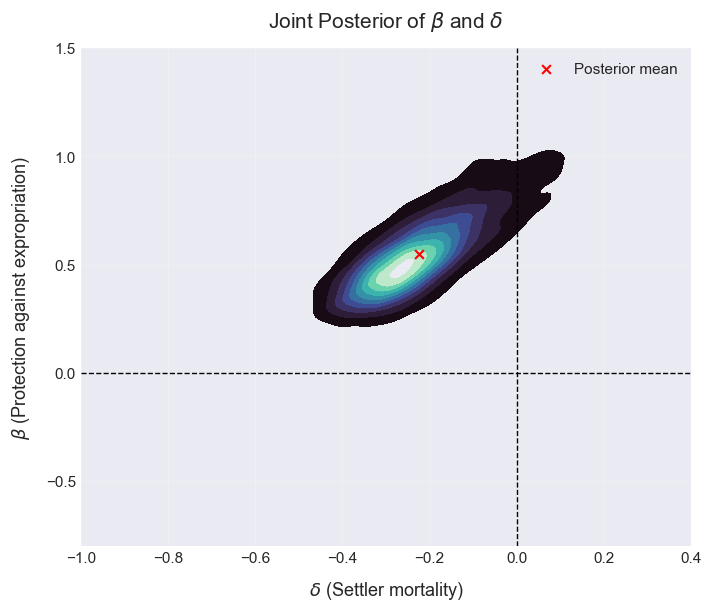

In [151]:
# Flatten posterior samples
beta = idata3.posterior["beta_orig"].values.flatten()
delta = idata3.posterior["delta_orig"].values.flatten()

# ---- Aesthetic setup ----
az.style.use("seaborn-v0_8-darkgrid")
plt.figure(figsize=(7, 6))

# ---- KDE contour ----
ax = sns.kdeplot(
    x=delta,
    y=beta,
    fill=True,
    levels=[0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95],
    cmap="mako",         # or "mako", "crest", "rocket", "cividis"
    linewidths=0.5
)

# ---- Labels and title ----
ax.set_xlabel(r"$\delta$ (Settler mortality)", fontsize=13, labelpad=10)
ax.set_ylabel(r"$\beta$ (Protection against expropriation)", fontsize=13, labelpad=10)
ax.set_title(r"Joint Posterior of $\beta$ and $\delta$", fontsize=15, pad=15)

# ---- Reference lines ----
ax.axvline(0, color="black", ls="--", lw=1)
ax.axhline(0, color="black", ls="--", lw=1)

# ---- Margins, ticks, and style ----
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="major", labelsize=11)
ax.grid(alpha=0.2)

# ---- Optional: mean point marker ----
ax.scatter(delta.mean(), beta.mean(), color="red", s=40, marker="x", label="Posterior mean")
ax.legend(frameon=False, loc="upper right", fontsize=11)
ax.set_xlim(-1.0, 0.4)
ax.set_ylim(-0.8, 1.5)


plt.show()


In [6]:

# Grid of S hyperparameters
S_grid = [0.0001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Helper to build priors
def priors_with_S(S_val, covariates=None):
    p = len(covariates) if covariates else 0
    FLAT = 1.0
    mus_t = [0.0] + [0.0]*p + [0.0]
    sig_t = [FLAT] + [FLAT]*p + [FLAT]
    mus_z = [0.0] + [0.0]*p + [0.94] + [0.0]  # delta mean = 0
    sig_z = [FLAT] + [FLAT]*p + [FLAT] + [FLAT]
    return {
        "mus": [mus_t, mus_z],
        "sigmas": [sig_t, sig_z],
        "eta": 2,
        "lkj_sd": 2,
        "S": S_val,
    }

rows = []
fits = []

for S_val in S_grid:
    print(f"\n--- Running model with S = {S_val} ---")
    pri = priors_with_S(S_val)

    out_name = f"ajr_iv_condS_{S_val:.2f}.nc"
    iv, idata = ajr.run(
        data=df_ajr,
        priors=pri,
        loosen_exclusion=True,
        covariates=None,
        draws=2000,
        tune=1000,
        chains=4,
        cores=4,
        target_accept=0.9,
        netcdf_path=out_name,
        stats=stats,
        standardize=True,
    )

    fits.append(idata)

    beta_mean = float(idata.posterior["beta_orig"].mean())
    beta_draws = idata.posterior["beta_orig"].values.ravel()
    # Use equal-tail 95% as a simple, stable fallback
    beta_low, beta_high = np.quantile(beta_draws, [0.025, 0.975])
    beta_low, beta_high = float(beta_low), float(beta_high)


    rows.append({
        "S": S_val,
        "beta_mean": beta_mean,
        "beta_hdi_low": beta_low,
        "beta_hdi_high": beta_high,
    })

summary = pd.DataFrame(rows)
print(summary)



--- Running model with S = 0.0001 ---
First-stage formula: avexpr ~ 1 + logem4
Structural formula: logpgp95 ~ 1 + avexpr + logem4


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z_raw, delta_cond, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 80 seconds.
Sampling: [likelihood]


Output()

...

c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z_raw, delta_cond, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 80 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

Posterior coefficients back-transformed to original units.
                    mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_z[Intercept] -0.002  0.082    -0.155      0.167      0.001    0.001   
beta_z[avexpr]     0.678  0.260     0.258      1.199      0.007    0.006   
beta_z[logem4]    -0.356  0.152    -0.622     -0.040      0.004    0.003   
beta_t[Intercept] -0.000  0.108    -0.213      0.208      0.001    0.001   
beta_t[logem4]    -0.515  0.110    -0.731     -0.298      0.001    0.001   

                   ess_bulk  ess_tail  r_hat  
beta_z[Intercept]  7281.730  4932.639  1.001  
beta_z[avexpr]     1670.479  1702.415  1.003  
beta_z[logem4]     1959.106  2112.140  1.002  
beta_t[Intercept]  7210.274  5233.033  1.001  
beta_t[logem4]     7218.239  4966.665  1.000  
                 mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
beta_orig       0.465  0.179     0.177      0.823      0.005    0.004   
delta_orig     -0.285  0.122    -0.499     -0.032      0

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]
C:\Users\B375471\AppData\Local\Temp\ipykernel_19968\4089993069.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


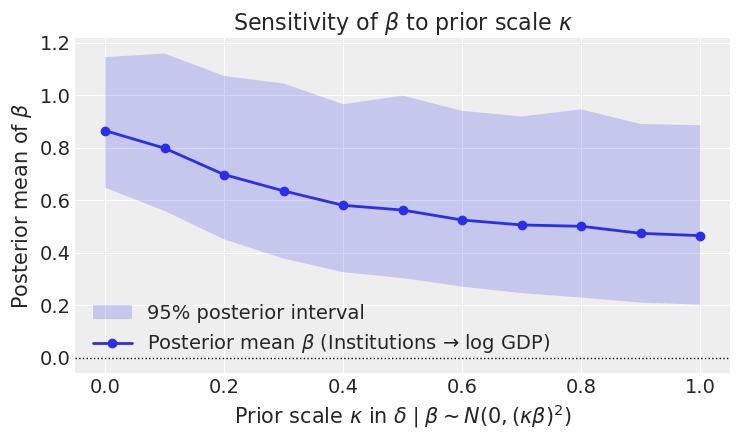

In [7]:
plt.figure(figsize=(7.5, 4.5))
plt.fill_between(summary["S"], summary["beta_hdi_low"], summary["beta_hdi_high"],
                 alpha=0.2, label="95% posterior interval")
plt.plot(summary["S"], summary["beta_mean"], marker="o", linewidth=2,
         label=r"Posterior mean $\beta$ (Institutions → log GDP)")


plt.axhline(0, linestyle=":", color="k", lw=1)

plt.xlabel(r"Prior scale $\kappa$ in $\delta \mid \beta \sim N(0,(\kappa\beta)^2)$")
plt.ylabel(r"Posterior mean of $\beta$")
plt.title(r"Sensitivity of $\beta$ to prior scale $\kappa$")
plt.legend()
plt.tight_layout()
plt.savefig("beta_sensitivity_to_S.png", dpi=160)
plt.show()


Shape check - first_stage_preds: (4, 2000, 64), observed_avexpr: (64,)
Instrument relevance (logem4 vs avexpr): -0.520
Rule of thumb: Should be > 0.3 for reasonable instrument strength
First-stage R-squared: 0.804


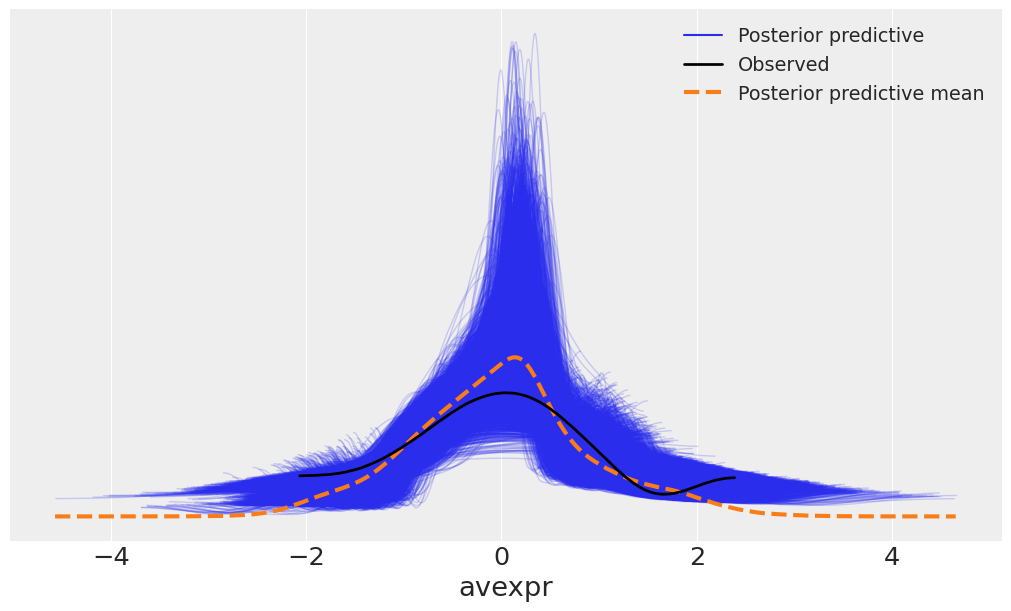

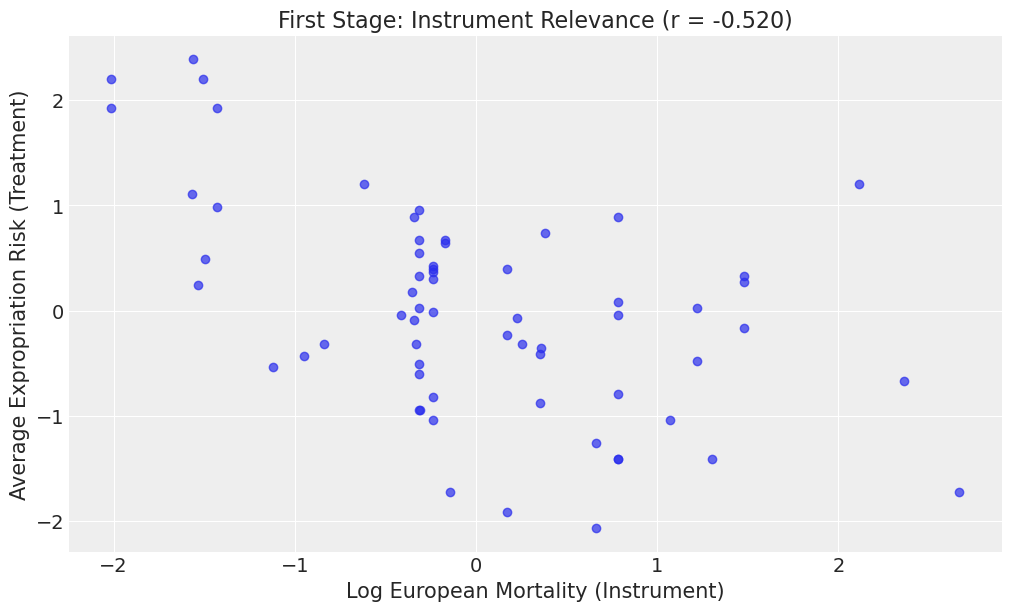

In [ ]:


# Use the same filtered data from above
first_stage_preds = idata.posterior['mu'].isel(mu_dim_1=0)  # First stage predictions
observed_avexpr = df_ajr['avexpr'].values

print(f"Shape check - first_stage_preds: {first_stage_preds.shape}, observed_avexpr: {observed_avexpr.shape}")

# CORRECT instrument relevance check: correlation between instrument (logem4) and treatment (avexpr)
instrument_treatment_corr = np.corrcoef(df_ajr['logem4'], df_ajr['avexpr'])[0,1]
print(f"Instrument relevance (logem4 vs avexpr): {instrument_treatment_corr:.3f}")
print("Rule of thumb: Should be > 0.3 for reasonable instrument strength")

# First-stage model fit: how well does the model predict avexpr?
if first_stage_preds.shape[2] == len(observed_avexpr):
    # Add first-stage PPC for visualization
    idata.posterior_predictive = idata.posterior_predictive.assign(
        avexpr=first_stage_preds.rename(mu_dim_0='avexpr_dim_0')
    )
    observed_avexpr_da = xr.DataArray(
        observed_avexpr, 
        dims=['avexpr_dim_0'],
        coords={'avexpr_dim_0': range(len(observed_avexpr))}
    )
    idata.observed_data = idata.observed_data.assign(avexpr=observed_avexpr_da)

    # Plot first-stage fit
    az.plot_ppc(idata, data_pairs={"avexpr": "avexpr"}, var_names=["avexpr"], figsize=(10, 6))
    
    # Model fit metrics (R-squared equivalent)
    pred_mean = first_stage_preds.mean(['chain', 'draw'])
    ss_res = np.sum((observed_avexpr - pred_mean)**2)
    ss_tot = np.sum((observed_avexpr - np.mean(observed_avexpr))**2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"First-stage R-squared: {r_squared:.3f}")
    
    
else:
    print("ERROR: Dimension mismatch!")
    print(f"Model predictions: {first_stage_preds.shape[2]}, Data observations: {len(observed_avexpr)}")



[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


Observed mean (raw): 0.000
Observed mean (centered): 0.000
Predicted mean (unchanged): -0.000
Observed std (raw): 1.035
Predicted std: 0.538


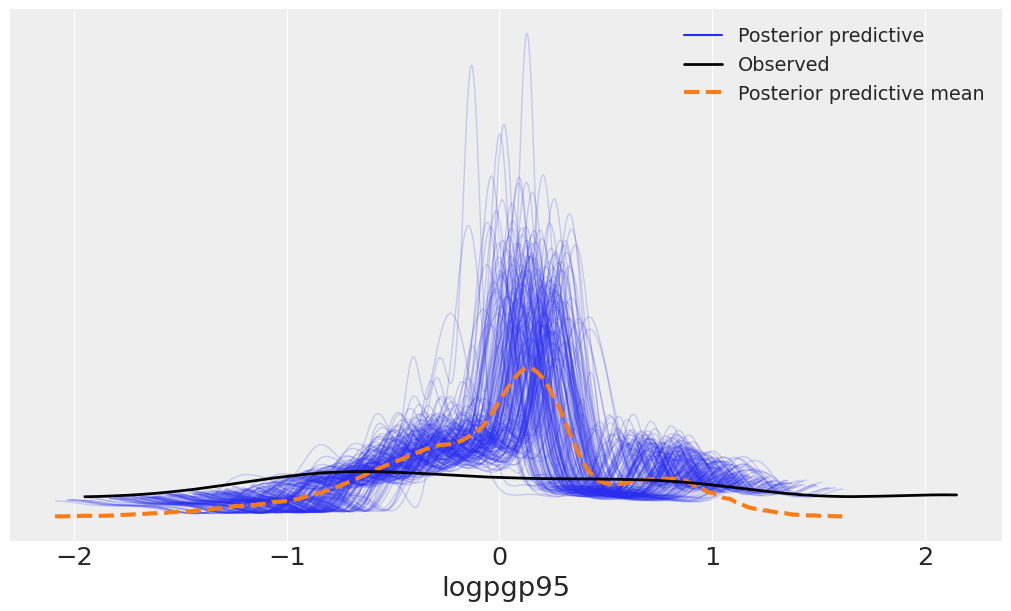

In [ ]:

idata3 = az.from_netcdf("ajr_iv_delta_posterior07.nc")

# Extract structural equation predictions (logpgp95) — UNCHANGED
structural_preds = idata3.posterior['mu'].isel(mu_dim_1=1)  # (chain, draw, obs)

observed_logpgp95 = df_ajr['logpgp95'].values

# --- center ONLY the observed ---
obs_mean = observed_logpgp95.mean()
observed_logpgp95_centered = observed_logpgp95 - obs_mean

# Add the logpgp95 predictions to posterior_predictive (UNSHIFTED)
idata3.posterior_predictive = idata3.posterior_predictive.assign(
    logpgp95=structural_preds.rename(mu_dim_0='logpgp95_dim_0')
)

# Add the CENTERED observed logpgp95 to observed_data (same var name)
observed_da = xr.DataArray(
    observed_logpgp95_centered,
    dims=['logpgp95_dim_0'],
    coords={'logpgp95_dim_0': range(len(observed_logpgp95_centered))}
)
idata3.observed_data = idata3.observed_data.assign(logpgp95=observed_da)

# Remove likelihood if present
if 'likelihood' in idata3.posterior_predictive:
    idata3.posterior_predictive = idata3.posterior_predictive.drop_vars('likelihood')
if 'likelihood' in idata3.observed_data:
    idata3.observed_data = idata3.observed_data.drop_vars('likelihood')

# PPC: predictive "logpgp95" vs observed "logpgp95" (now centered)
az.plot_ppc(
    idata3,
    data_pairs={"logpgp95": "logpgp95"},
    var_names=["logpgp95"],
    figsize=(10, 6),
    kind="kde",                 # smoother
    num_pp_samples=200,         # fewer overlays
    random_seed=1,
)

# Set the ylabel after creating the plot
plt.ylabel("Centered $Y_i$ (log GDP per capita)")
plt.show()

print(f"Observed mean (raw): {obs_mean:.3f}")
print(f"Observed mean (centered): {observed_logpgp95_centered.mean():.3f}")
print(f"Predicted mean (unchanged): {float(structural_preds.mean()):.3f}")
print(f"Observed std (raw): {observed_logpgp95.std():.3f}")
print(f"Predicted std: {float(structural_preds.std()):.3f}")
